In [2]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import pandas as pd

# compiling dfs
folder = Path('./output/classif_grid2_90t4c')
subfolders = ['t1','t2','t3','t4','t5']

dev = merge_devtest_csvs(folder, subfolders, 'dev.csv')#, save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv')#, save=True)

# get confs, update
confs = ConfigLookup(
    keys=['method', 'mlp'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    # save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

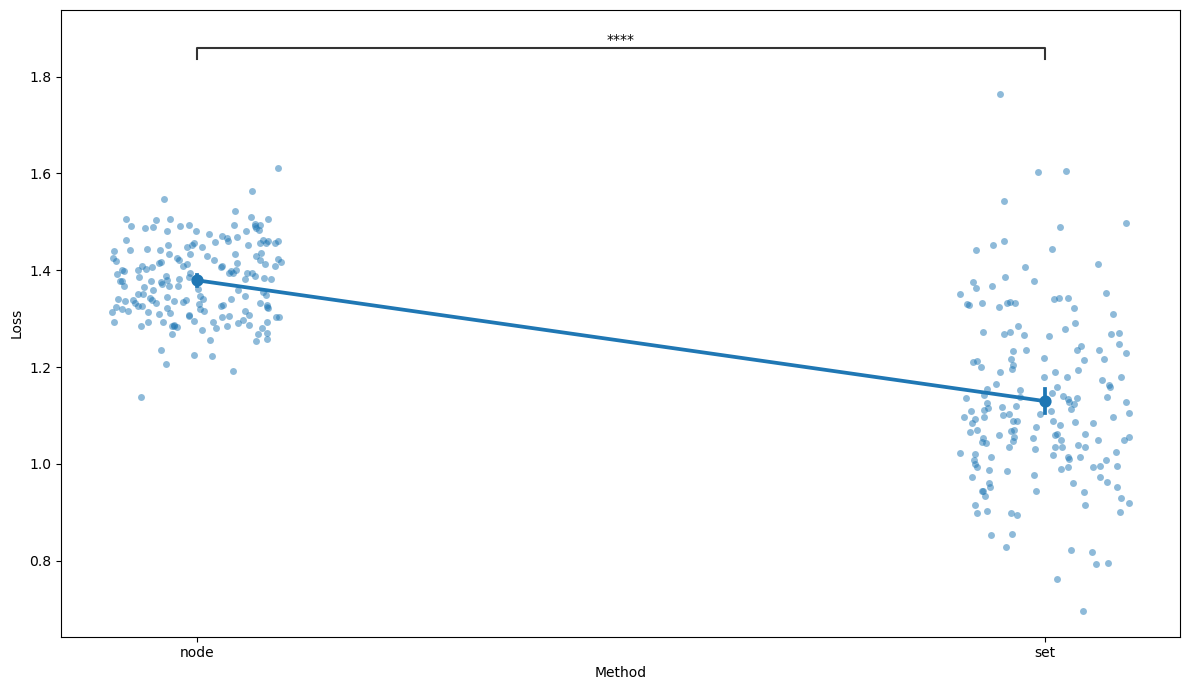

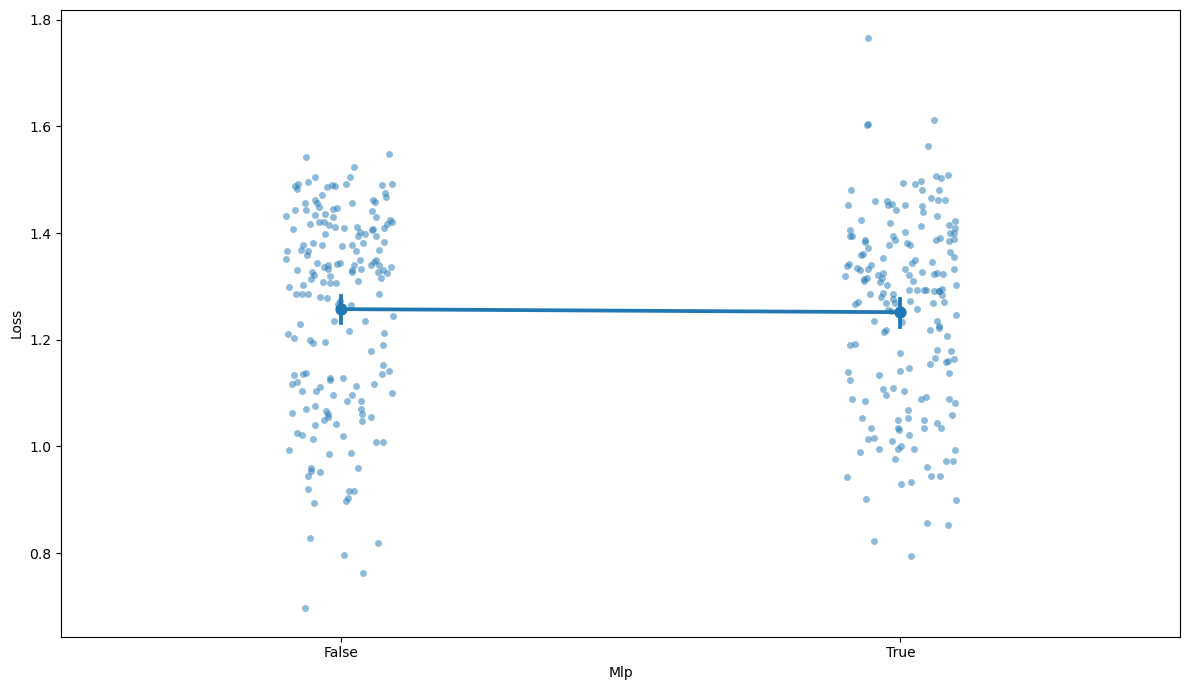

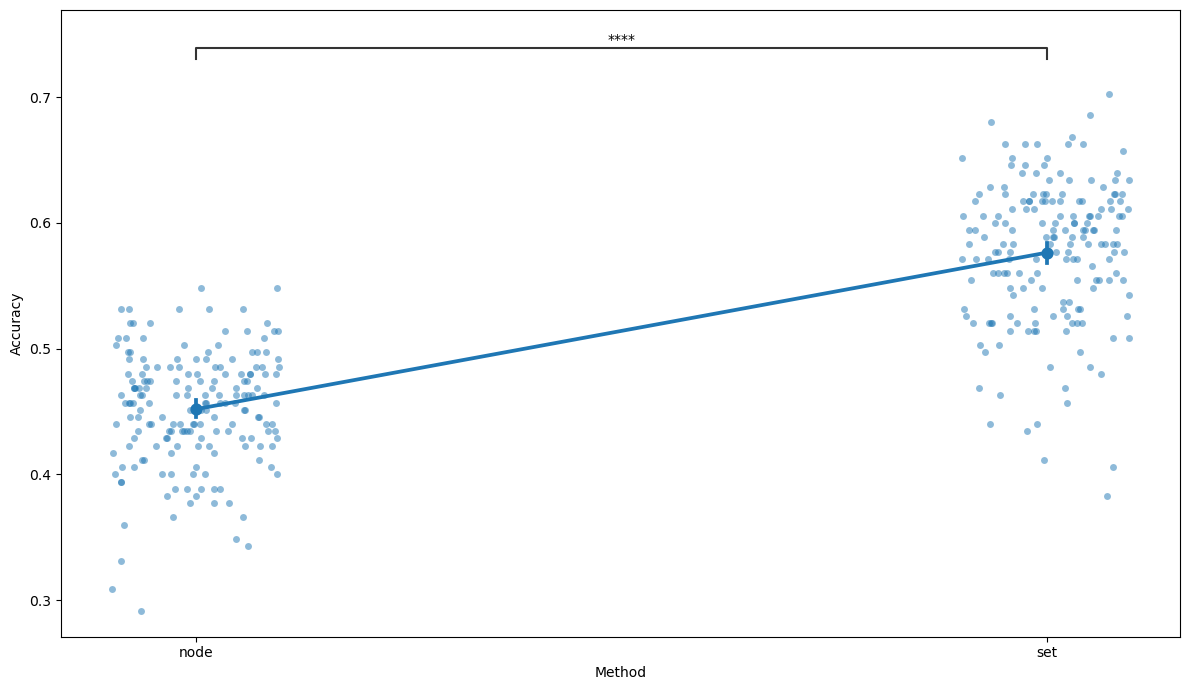

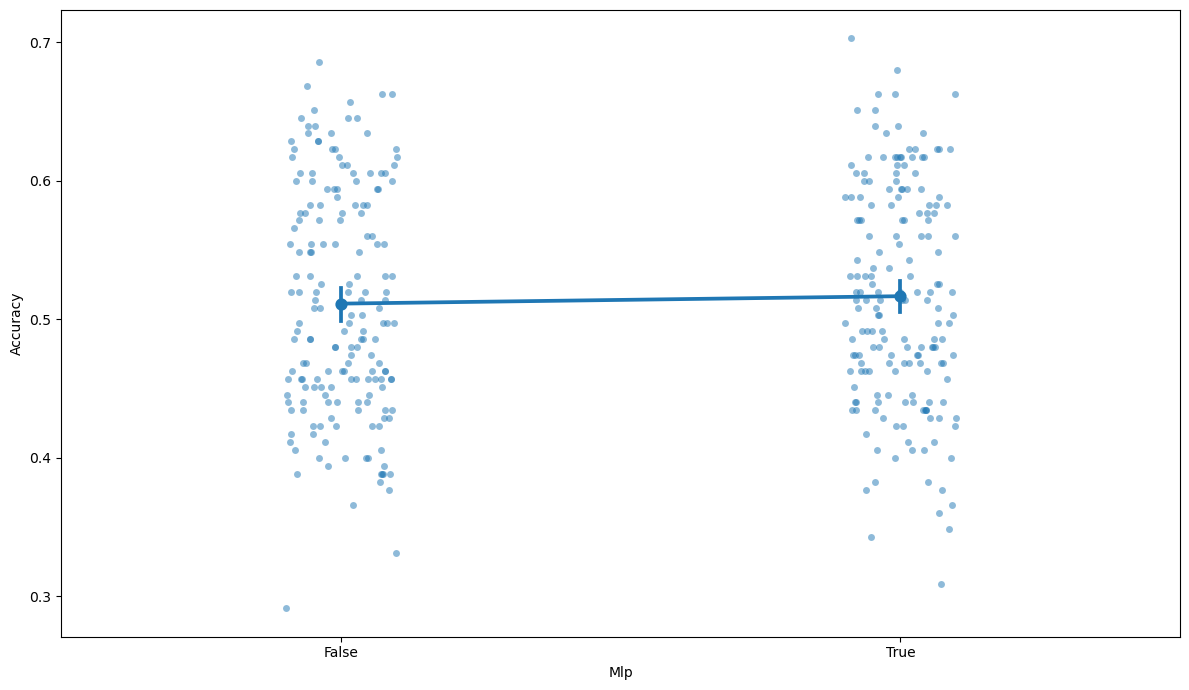

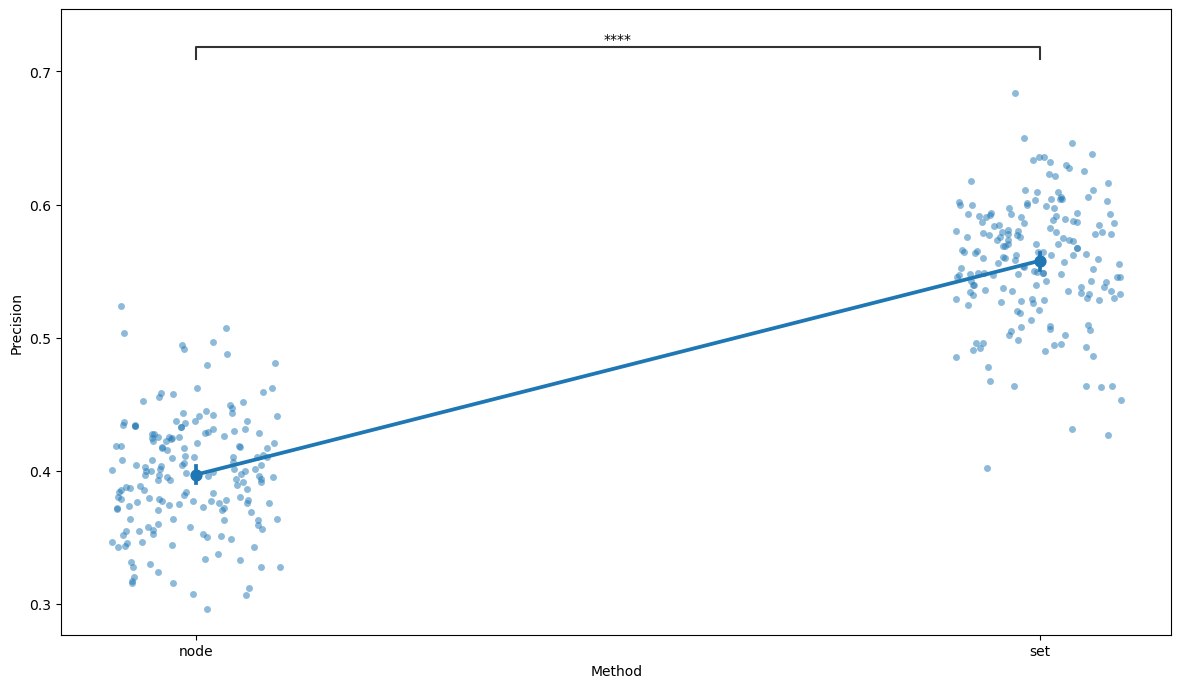

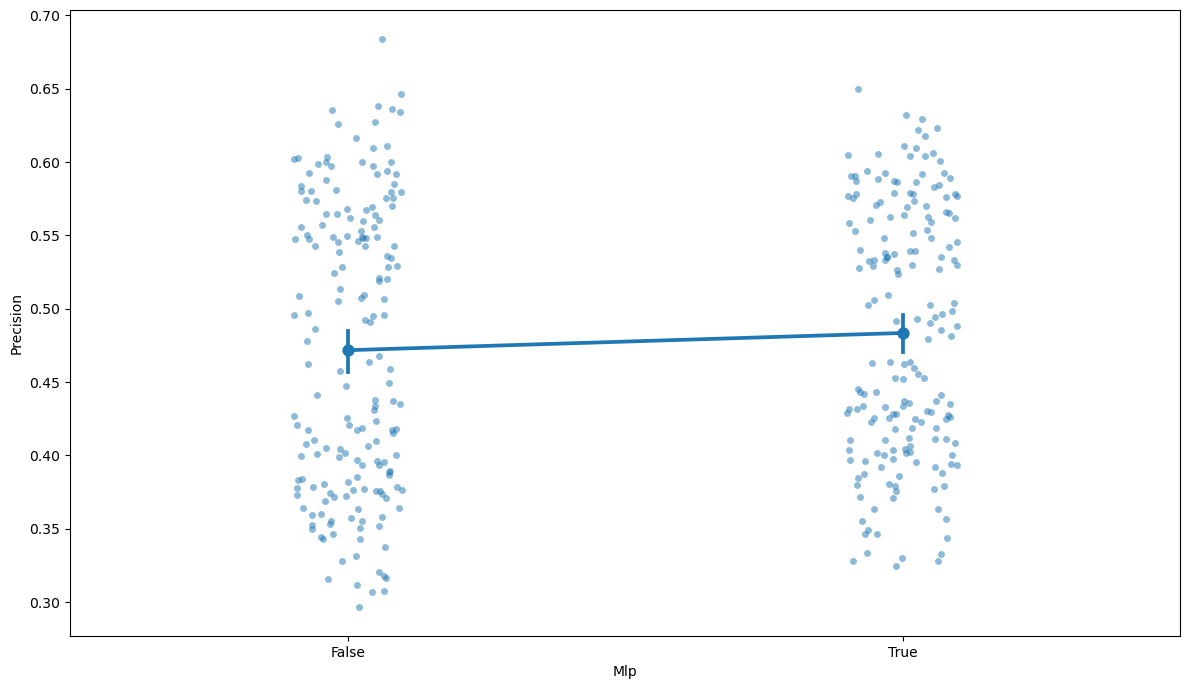

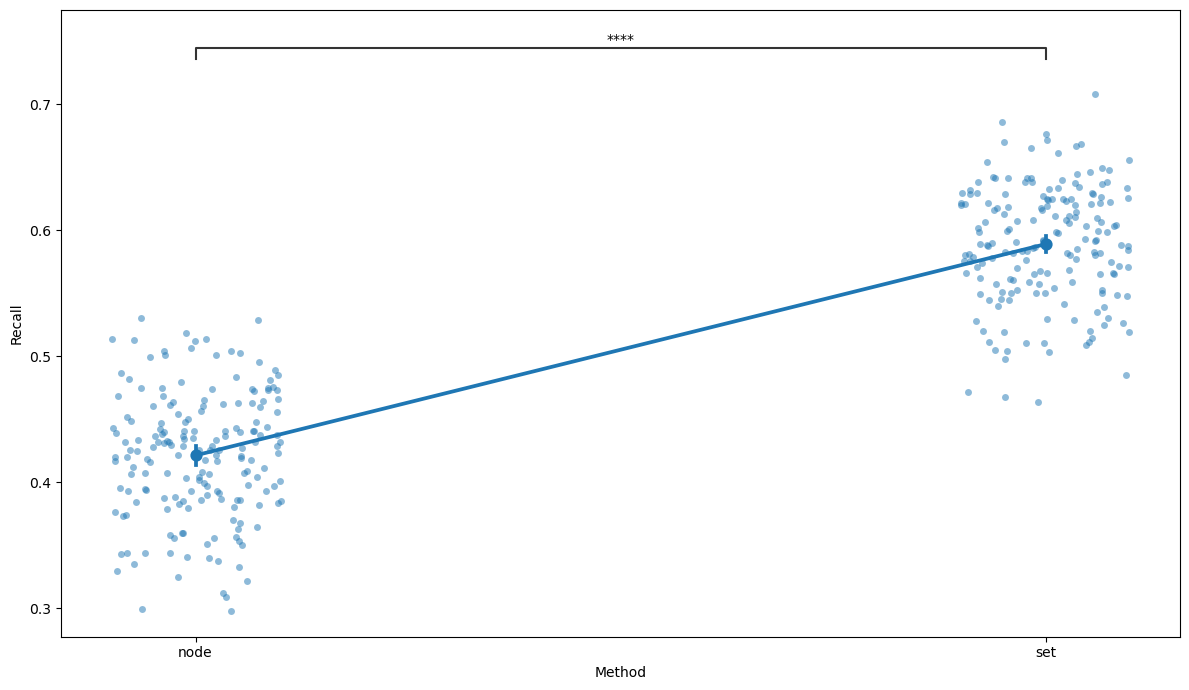

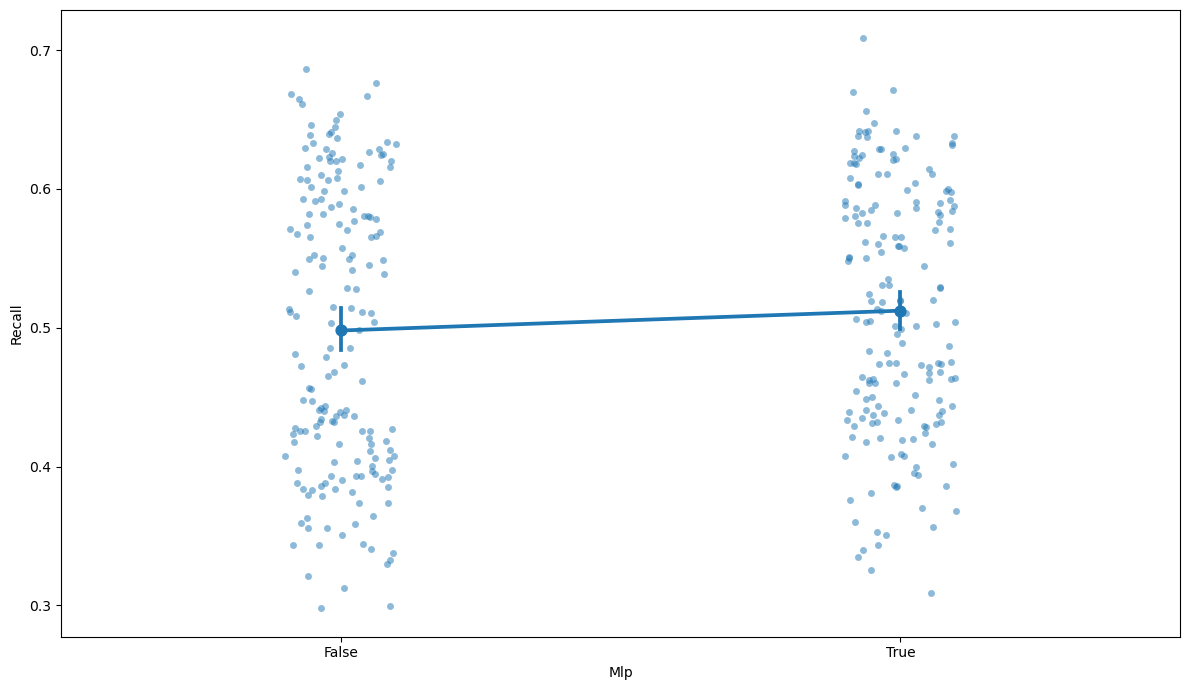

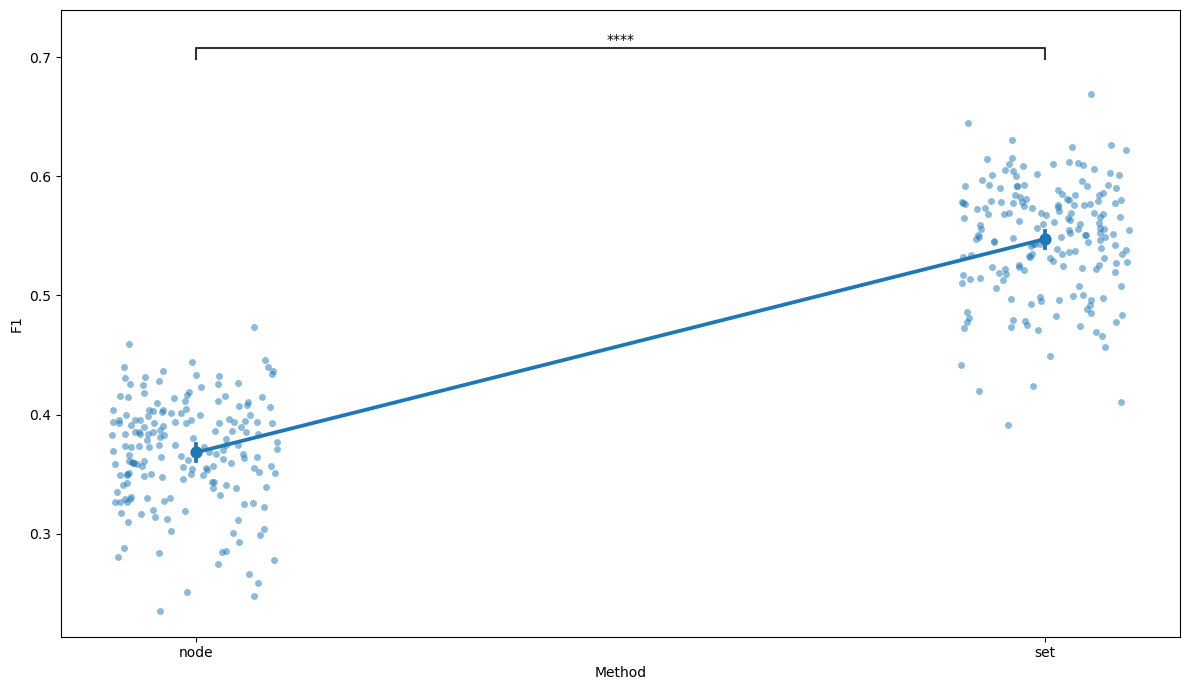

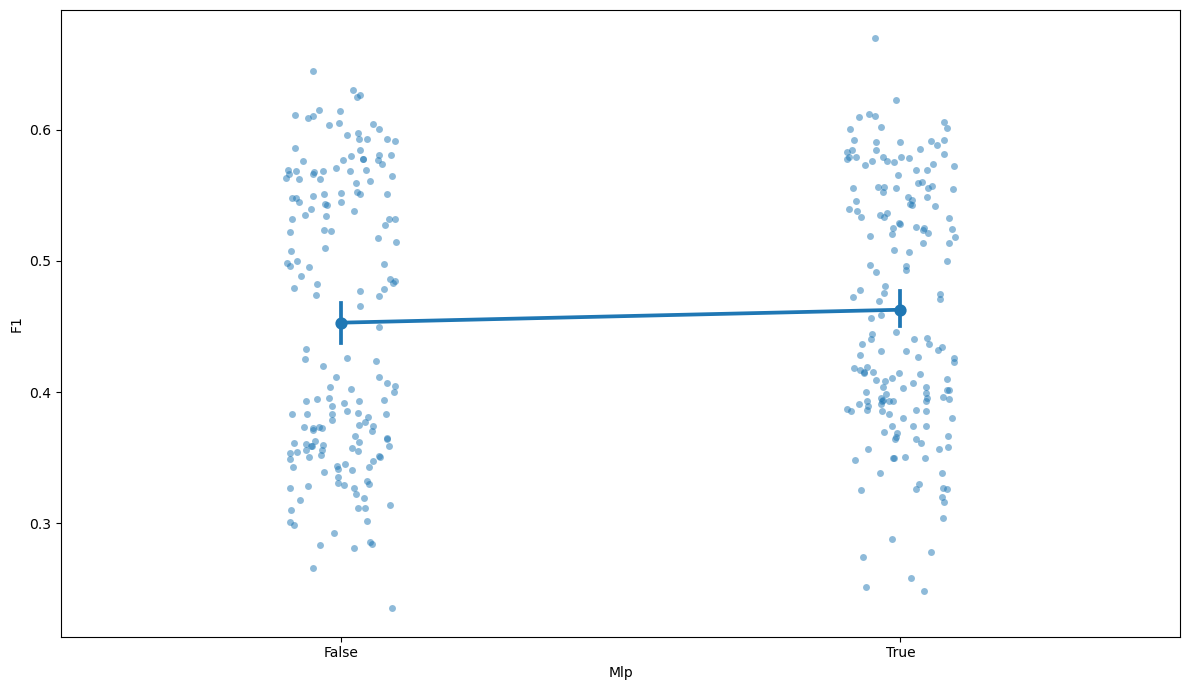

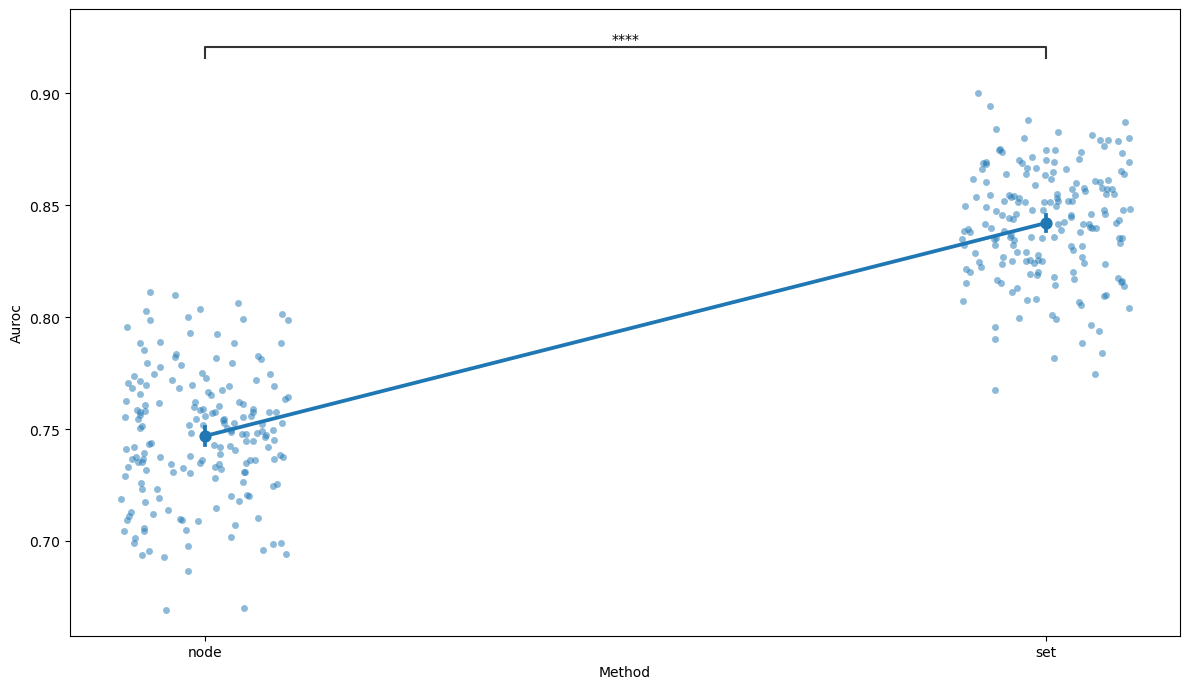

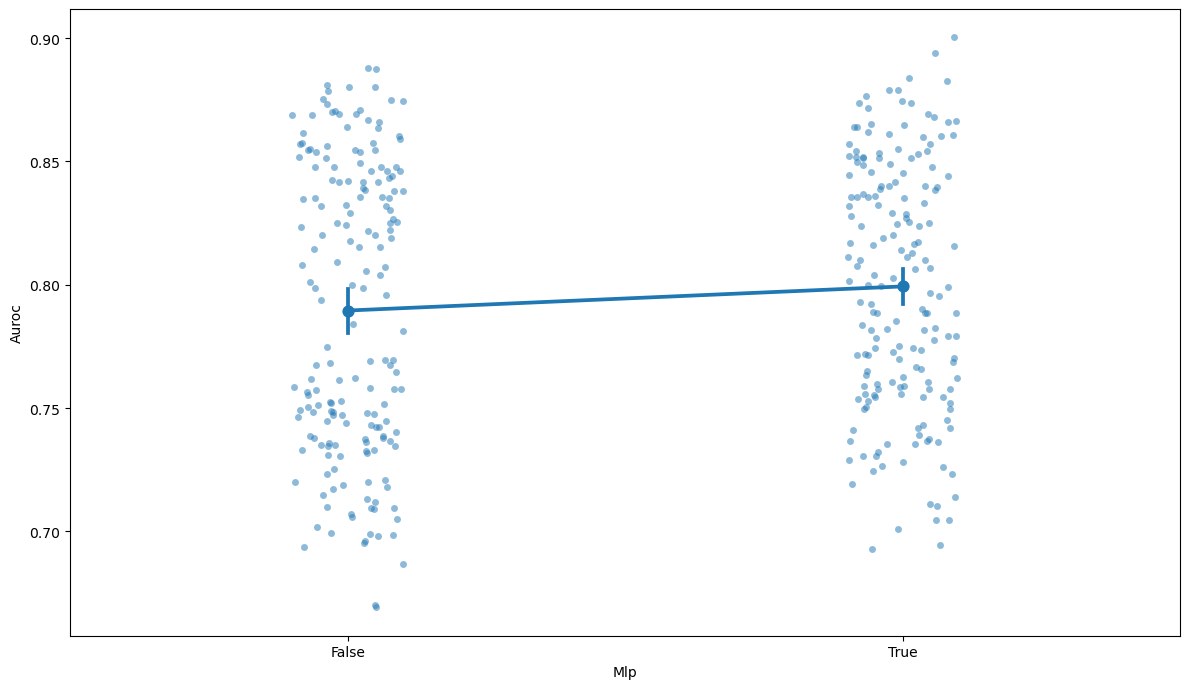

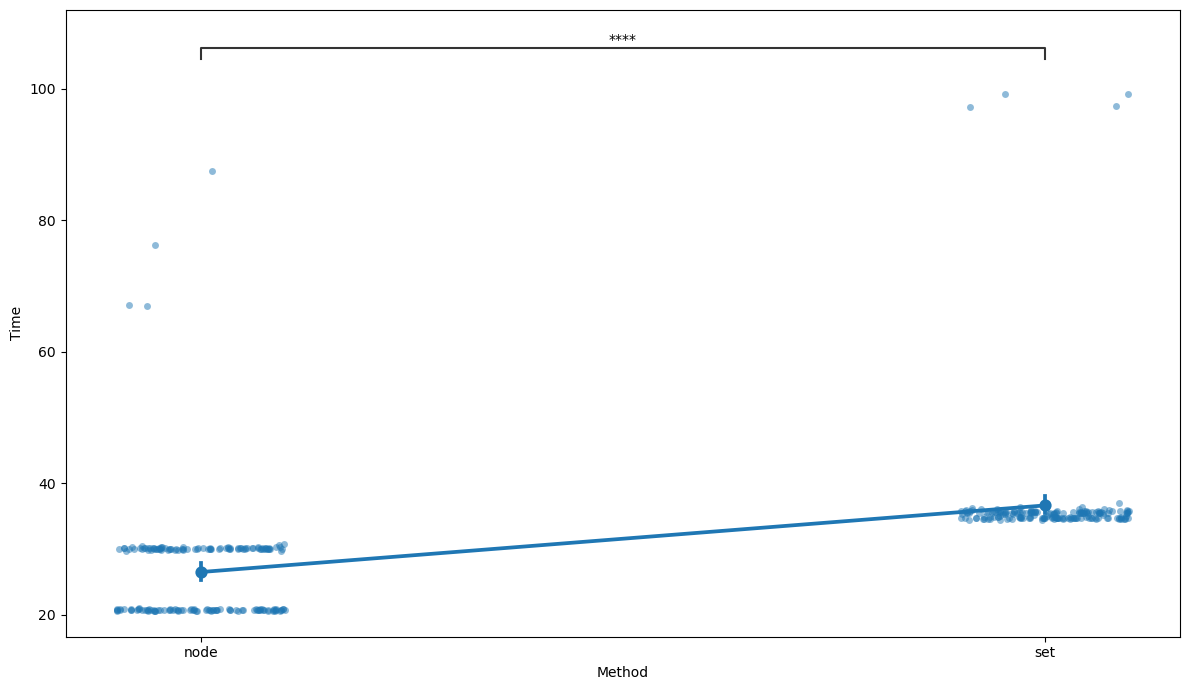

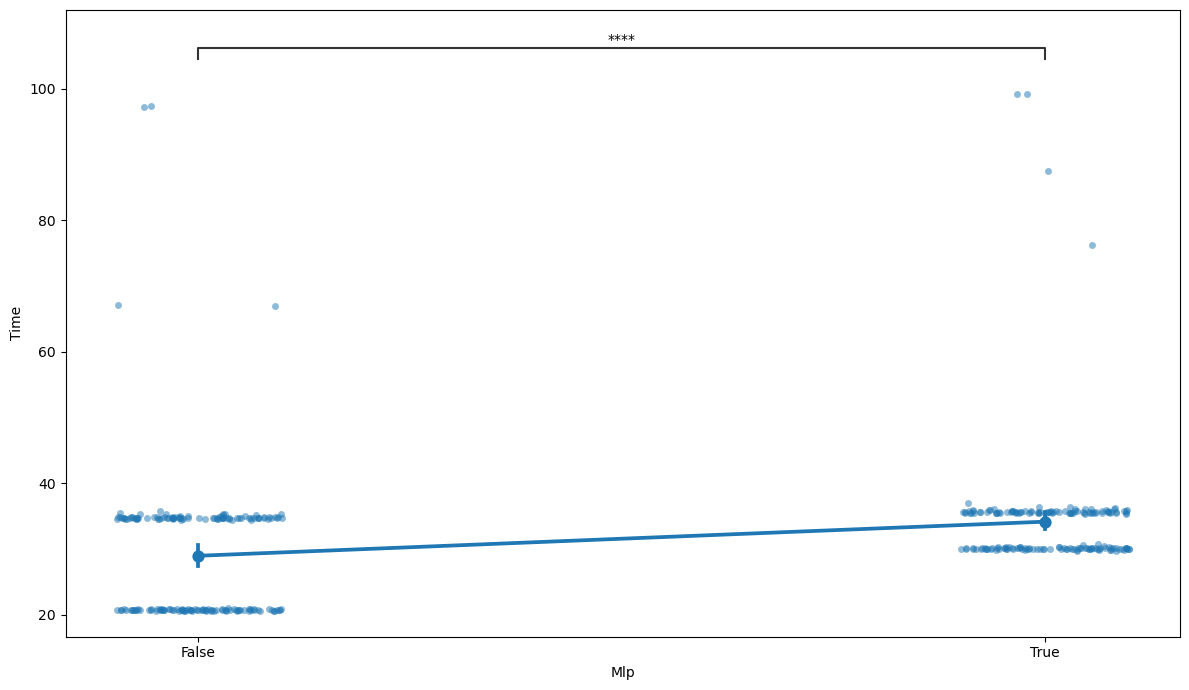

In [3]:
metric_x_point(
    df=test,
    cols=['method', 'mlp'],
    # metrics=['accuracy'],
    figsize=(12,7),
    strip=True
)

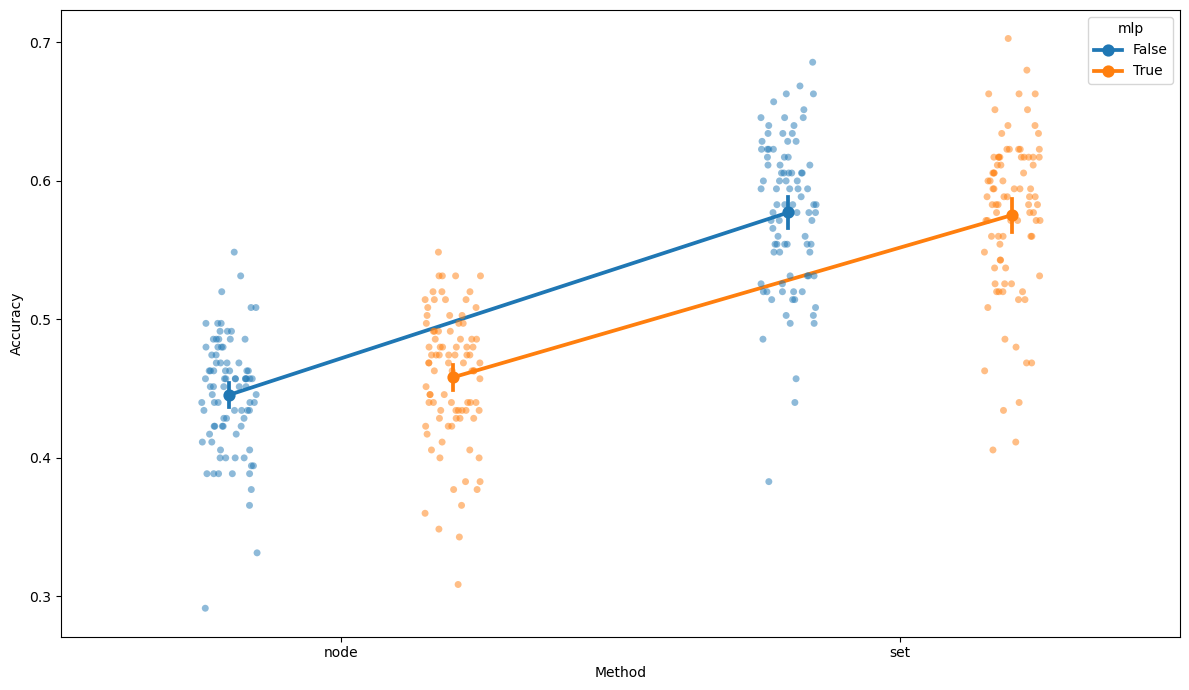

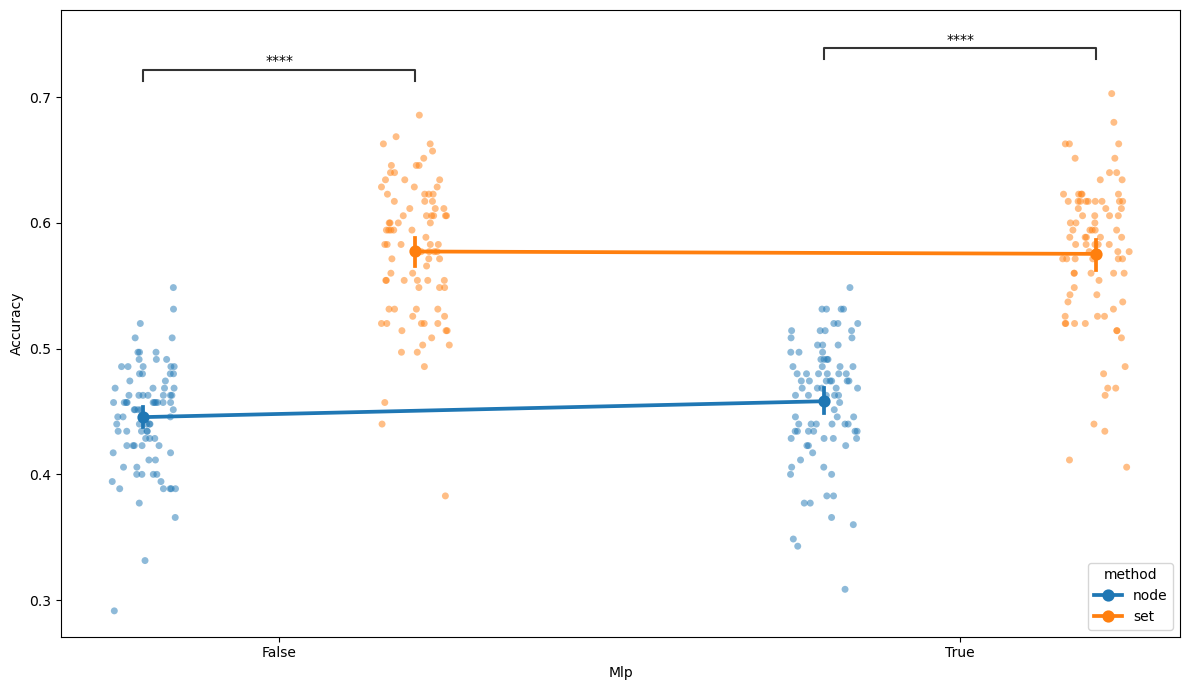

In [5]:
metric_x_point(
    df=test,
    cols=['method', 'mlp'],
    metrics=['accuracy'],
    hue=True,
    figsize=(12,7),
    strip=True,
)